<a href="https://colab.research.google.com/github/steffiprog/Customer-Segmentation-ML-Project-HSE/blob/main/clustering_clients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import os

# Загрузка датасета и получение пути к файлам
files_path = kagglehub.dataset_download("jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store")
print(f"Файлы датасета загружены в: {files_path}")

100%|██████████| 3.13M/3.13M [00:00<00:00, 120MB/s]

Extracting files...
Файлы датасета загружены в: /root/.cache/kagglehub/datasets/jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store/versions/6


1. Загрузка и предобработка

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [9]:
import pandas as pd
import os

# Проверим содержимое папки, куда были загружены файлы
print(f"Содержимое папки {files_path}:")
print(os.listdir(files_path))

csv_file_path = os.path.join(files_path, 'users.6M0xxK.2024.public.csv')
df = pd.read_csv(csv_file_path)

Содержимое папки /root/.cache/kagglehub/datasets/jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store/versions/6:
['countries_with_top_sellers_fashion_c2c.csv', 'users.6M0xxK.2024.public.csv', 'comparison_of_sellers_by_gender_and_country.csv', 'users.6M0xxK.2020.public.csv', '6M-0K-99K.users.dataset.public.csv']


In [11]:
df.head()

,identifierHash,type,countryCode,country,language,socialNbFollowers,socialNbFollows,socialProductsLiked,productsListed,productsSold,...,productsWished,productsBought,gender,civilityGenderId,civilityTitle,hasProfilePicture,seniority,seniorityAsMonths,seniorityAsYears,websiteLongevity
0,1920991140,user,us,Etats-Unis,en,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
1,1920860068,user,se,Suède,en,3,8,1,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
2,1920401316,user,it,Italie,fr,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803
3,1919811492,user,dk,Danemark,en,75,10,1968,0,0,...,43,15,M,1,mr,True,3206,106.87,8.91,3803
4,1919025060,user,de,Allemagne,de,3,8,0,0,0,...,0,0,M,1,mr,True,3206,106.87,8.91,3803


In [13]:
clustering_features = [
    'socialNbFollowers', 'socialNbFollows', 'socialProductsLiked',
    'productsListed', 'productsSold', 'productsPassRate',
    'productsWished', 'productsBought', 'seniorityAsYears'
]
# Выбираем только числовые признаки для кластеризации
X = df[clustering_features].copy()

In [14]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. K-Means с выбором K (локоть + силуэт)

In [15]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=160140.2, Silhouette=0.711
K=3: WCSS=136554.9, Silhouette=0.700
K=4: WCSS=116908.0, Silhouette=0.781
K=5: WCSS=96132.5, Silhouette=0.794
K=6: WCSS=81852.9, Silhouette=0.797
K=7: WCSS=70310.1, Silhouette=0.800
K=8: WCSS=59180.5, Silhouette=0.800
K=9: WCSS=51706.1, Silhouette=0.805
K=10: WCSS=46504.1, Silhouette=0.810


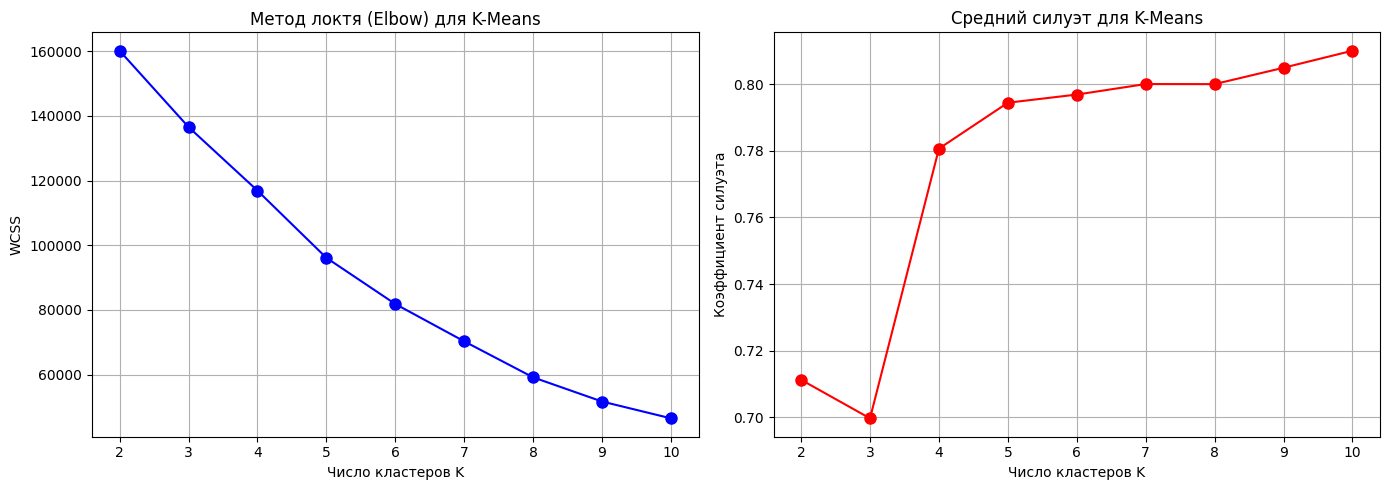

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {optimal_k}")


Оптимальное число кластеров по силуэту: 10


In [20]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

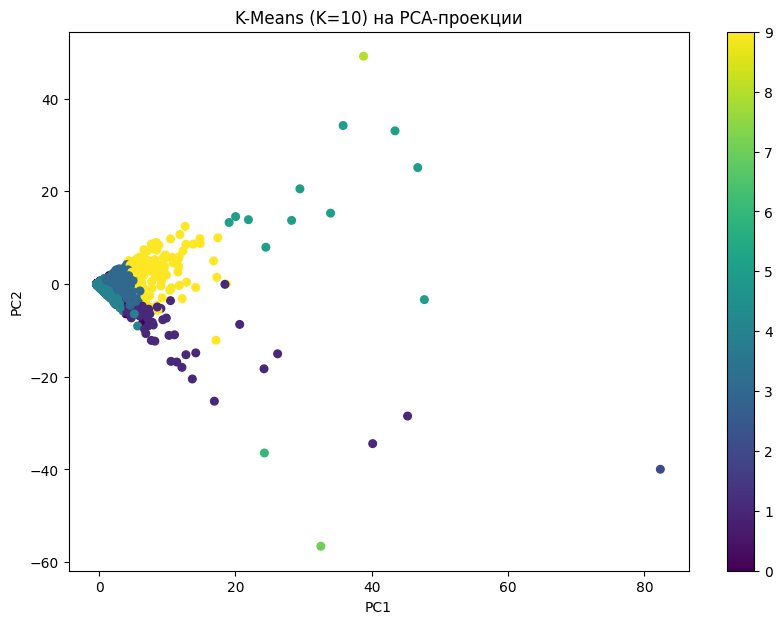

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter)
plt.show()

In [30]:
import pandas as pd

# Подсчет количества пользователей в каждом кластере
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_values(ascending=False)

print("Количество пользователей в каждом кластере:")
print(cluster_counts)

# Выбираем 4 крупнейших кластера
top_4_clusters = cluster_counts.head(4).index.tolist()
print(f"\nТоп 4 крупнейших кластера: {top_4_clusters}")

# Добавляем метки кластеров к исходному DataFrame
df['cluster_label'] = kmeans_labels

# Фильтруем данные для выбранных кластеров
df_top_clusters = df[df['cluster_label'].isin(top_4_clusters)]

# Вычисляем средние значения для выбранных признаков в этих кластерах
cluster_characteristics_top_4 = df_top_clusters.groupby('cluster_label')[clustering_features].mean()

print("\nСредние характеристики пользователей в 4 крупнейших кластерах:")
print(cluster_characteristics_top_4)


Количество пользователей в каждом кластере:
0    11379
4     7348
3     1803
9      150
1       48
5       11
6        1
7        1
2        1
8        1
Name: count, dtype: int64

Топ 4 крупнейших кластера: [0, 4, 3, 9]

Средние характеристики пользователей в 4 крупнейших кластерах:
               socialNbFollowers  socialNbFollows  socialProductsLiked  \
cluster_label                                                            
0                       6.292996         8.886194            28.939801   
3                      31.596783        15.252912           116.628397   
4                       6.380103         8.959036            34.078661   
9                     209.966667       185.760000           368.453333   

               productsListed  productsSold  productsPassRate  productsWished  \
cluster_label                                                                   
0                    0.048247      0.135073          0.078390        7.647245   
3                    2.4331

**Анализ 4 наибольших кластеров (4 основных типа клиентов)**

1. *11379: Пассивные Пользователи/Покупатели:*

Профиль активности: Эти пользователи демонстрируют очень низкую социальную активность (мало подписчиков/подписок), почти не выставляют и не продают товары, а также имеют очень низкий процент успешных продаж. В основном они взаимодействуют, ставя лайки и добавляя товары в избранное, а также совершают скромные покупки.
Стаж: Эта группа имеет самый высокий средний стаж среди четырех, что указывает на длительное, но пассивное вовлечение в платформу.
Общее описание: Это самый многочисленный сегмент долгосрочных пользователей, которые в основном являются потребителями с минимальной активностью в продажах.

2. *7348: Вовлеченные Пользователи:*

Профиль активности: Похожи на Кластер 0, но со слегка более высокими средними показателями по большинству метрик активности. У них немного больше социальных взаимодействий, они лайкают немного больше товаров и показывают немного лучший, хотя все еще очень низкий, процент успешных продаж.
Стаж: Немного менее опытные, чем пользователи Кластера 0.
Общее описание: Еще одна большая группа пользователей, которые в основном являются потребителями, показывающие немного больше взаимодействия, чем Кластер 0, но все еще не являются активными продавцами.

3. *1803: Активные и Успешные Продавцы:*

Профиль активности: Этот кластер характеризуется значительно более высокой социальной активностью и существенной активностью в выставлении и продаже товаров. У них очень высокий productsPassRate (86.31%), что указывает на успешные продажи.
Сбалансированное взаимодействие: Они также активно добавляют товары в избранное и покупают, демонстрируя более сбалансированное вовлечение как продавцов, так и покупателей.
Стаж: Эта группа также имеет высокий средний стаж, что указывает на опытных и эффективных пользователей.
Общее описание: Ключевой сегмент активных и успешных продавцов, которые являются неотъемлемой частью объема транзакций на платформе.

4. *150: Продвинутые Пользователи/Инфлюенсеры*

Профиль активности: Это самая высокоактивная группа по всем показателям. У них очень большая социальная сеть, они выставляют и продают большое количество товаров с отличным процентом успешных продаж, а также активно добавляют в избранное и покупают товары.
Стаж: Как и Кластер 3, они обладают высоким средним стажем.
Общее описание: Небольшая, но влиятельная группа пользователей, которые, вероятно, значительно способствуют социальной и коммерческой активности платформы, возможно, выступая в роли инфлюенсеров или профессиональных продавцов.
Таким образом, кластеры показывают иерархию вовлеченности: от большой базы пассивных, долгосрочных потребителей (Кластеры 0 и 4) до меньших, высокоактивных и успешных продавцов/инфлюенсеров (Кластеры 3 и 9).